# Alternative Data Phase Test v2 — All 8 Data Sources

**10 experiments** testing each data source individually + combined.
Same BiGRU model for all. No tuning. Pure feature ablation.

| # | Data Source | Type |
|---|-----------|------|
| 1 | FRED-MD (baseline) | Macroeconomic |
| 2 | Technical Indicators | Price microstructure |
| 3 | CFTC COT | Market positioning |
| 4 | Cross-Commodity (corn, soy, oil, USD, gold) | Demand dynamics |
| 5 | Google Trends | Public attention |
| 6 | Weather (Kansas + North Dakota) | Supply/growing conditions |
| 7 | VIX + OVX | Market fear/sentiment |
| 8 | NASA POWER (ag parameters) | Vegetation/climate proxy |

In [3]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except: pass

if IN_COLAB:
    BASE_DIR = '/content/drive/MyDrive/Quants '
    QUANTS_DIR = BASE_DIR
else:
    BASE_DIR = '/Users/np3129/Documents/AI_ML_Quants_VIP'
    QUANTS_DIR = os.path.join(BASE_DIR, 'Quants data', 'Quants ')

ALT = os.path.join(BASE_DIR, 'alternative_data', 'raw')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Bidirectional, GRU, Dense,
                                     GlobalAveragePooling1D, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print(f'Running on: {"Colab" if IN_COLAB else "Local"}')
print(f'Data: {QUANTS_DIR}')
print(f'Alt data: {ALT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on: Colab
Data: /content/drive/MyDrive/Quants 
Alt data: /content/drive/MyDrive/Quants /alternative_data/raw


## 1. Load Wheat Prices

In [4]:
inv = os.path.join(QUANTS_DIR, 'Investing.com')
pf = sorted([f for f in os.listdir(inv) if f.endswith('.csv') and 'Wheat' in f])
wheat = pd.concat([pd.read_csv(os.path.join(inv,f)) for f in pf], ignore_index=True)
wheat['Date'] = pd.to_datetime(wheat['Date'], format='mixed', dayfirst=False)
wheat = wheat.sort_values('Date').drop_duplicates(subset='Date').reset_index(drop=True)
for c in ['Price','Open','High','Low']:
    wheat[c] = pd.to_numeric(wheat[c].astype(str).str.replace(',',''), errors='coerce')
def pvol(v):
    v=str(v).strip().replace(',','')
    if v.endswith('K'): return float(v[:-1])*1000
    elif v.endswith('M'): return float(v[:-1])*1e6
    try: return float(v)
    except: return np.nan
wheat['Volume'] = wheat['Vol.'].apply(pvol)
wheat = wheat.dropna(subset=['Price']).reset_index(drop=True)
print(f'Wheat: {len(wheat)} days, {wheat["Date"].min().date()} to {wheat["Date"].max().date()}')

Wheat: 6864 days, 1999-08-01 to 2025-12-12


## 2. FRED-MD

In [5]:
FF = ['RPI','W875RX1','CMRMTSPLx','IPFPNSS','USWTRADE','USTRADE','BUSLOANS','CONSPI',
    'S&P 500','S&P PE ratio','FEDFUNDS','TB3MS','TB6MS','GS1','GS5','GS10','AAA','BAA',
    'TB3SMFFM','TB6SMFFM','T1YFFM','T5YFFM','T10YFFM','AAAFFM','BAAFFM',
    'EXSZUSx','EXJPUSx','EXUSUKx','EXCAUSx','PPICMM','UMCSENTx']
fr = pd.read_csv(os.path.join(QUANTS_DIR,'FredMD_Dataset','2025-10-MD.csv'))
tc = fr.iloc[0]; fd = fr.iloc[1:].copy()
fd['sasdate'] = pd.to_datetime(fd['sasdate']); fd = fd.rename(columns={'sasdate':'Date'})
av = [f for f in FF if f in fd.columns]; fd = fd[['Date']+av].copy()
for c in av: fd[c] = pd.to_numeric(fd[c], errors='coerce')
tm = {}
for f in av:
    try: tm[f] = int(float(tc.get(f,1)))
    except: tm[f] = 1
def atc(s,t):
    if t==1: return s
    elif t==2: return s.diff()
    elif t==3: return s.diff().diff()
    elif t==4: return np.log(s.clip(lower=1e-10))
    elif t==5: return np.log(s.clip(lower=1e-10)).diff()
    elif t==6: return np.log(s.clip(lower=1e-10)).diff().diff()
    return s
for c in av: fd[c] = atc(fd[c], tm[c])
fd = fd.dropna().reset_index(drop=True)
fd['Date'] = fd['Date'] + pd.DateOffset(months=1)
fred_daily = fd.set_index('Date').resample('D').ffill().reset_index()
fred_cols = [c for c in fred_daily.columns if c!='Date']
print(f'FRED-MD: {len(fred_cols)} features')

FRED-MD: 31 features


## 3. Technical Indicators

In [6]:
def comp_tech(df):
    o = pd.DataFrame(index=df.index)
    c,h,l,v = df['Price'],df['High'],df['Low'],df['Volume'].fillna(0)
    for n in [5,10,20]: o[f'mom_{n}d'] = c.pct_change(n)
    d=c.diff(); g=d.clip(lower=0); lo=(-d).clip(lower=0)
    o['rsi']=100-(100/(1+g.rolling(14).mean()/lo.rolling(14).mean().replace(0,np.nan)))
    e12,e26=c.ewm(span=12).mean(),c.ewm(span=26).mean()
    macd=e12-e26; o['macd']=macd; o['macd_hist']=macd-macd.ewm(span=9).mean()
    s20,st20=c.rolling(20).mean(),c.rolling(20).std()
    o['bb_pctb']=(c-(s20-2*st20))/(4*st20).replace(0,np.nan)
    tr=pd.concat([h-l,(h-c.shift(1)).abs(),(l-c.shift(1)).abs()],axis=1).max(axis=1)
    o['atr']=tr.rolling(14).mean()
    o['vol_sma']=v/v.rolling(20).mean().replace(0,np.nan)
    return o
tech = comp_tech(wheat); tech_cols = tech.columns.tolist()
wheat = pd.concat([wheat, tech], axis=1)
print(f'Tech indicators: {tech_cols}')

Tech indicators: ['mom_5d', 'mom_10d', 'mom_20d', 'rsi', 'macd', 'macd_hist', 'bb_pctb', 'atr', 'vol_sma']


## 4. CFTC COT

In [7]:
cr = pd.read_csv(os.path.join(ALT,'cot_wheat_disaggregated.csv'))
cr['Date'] = pd.to_datetime(cr['Report_Date_as_YYYY-MM-DD'])
nc=['Open_Interest_All','Prod_Merc_Positions_Long_All','Prod_Merc_Positions_Short_All',
    'M_Money_Positions_Long_All','M_Money_Positions_Short_All']
for c in nc: cr[c]=pd.to_numeric(cr[c],errors='coerce')
cot=cr.groupby('Date')[nc].sum().reset_index()
oi=cot['Open_Interest_All'].replace(0,np.nan)
cot['mm_net']=cot['M_Money_Positions_Long_All']-cot['M_Money_Positions_Short_All']
cot['cm_net']=cot['Prod_Merc_Positions_Long_All']-cot['Prod_Merc_Positions_Short_All']
cot['hedge_pr']=cot['cm_net']/oi; cot['spec_se']=cot['mm_net']/oi
cot['pos_chg']=cot['mm_net'].diff(4)
cot['spec_z']=(cot['mm_net']-cot['mm_net'].rolling(52).mean())/cot['mm_net'].rolling(52).std().replace(0,np.nan)
cot['oi_lev']=cot['Open_Interest_All']
cot_features=['hedge_pr','spec_se','pos_chg','spec_z','oi_lev']
cot['Date']=cot['Date']+pd.Timedelta(days=3)
cot_d=cot[['Date']+cot_features].set_index('Date').resample('D').ffill().reset_index()
print(f'COT: {len(cot_d)} rows, {cot_features}')

COT: 4740 rows, ['hedge_pr', 'spec_se', 'pos_chg', 'spec_z', 'oi_lev']


## 5. Cross-Commodity Prices

In [8]:
ca={'corn_futures.csv':'corn','soybean_futures.csv':'soy','crude_oil_wti.csv':'oil',
    'usd_index.csv':'usd','gold_futures.csv':'gold'}
cdfs=[]
for fn,lb in ca.items():
    d=pd.read_csv(os.path.join(ALT,fn),header=[0,1],index_col=0,parse_dates=True)
    d.columns=[c[0] for c in d.columns]; d=d.reset_index()
    d['Date']=pd.to_datetime(d['Date']); d[f'{lb}_cl']=pd.to_numeric(d['Close'],errors='coerce')
    cdfs.append(d[['Date',f'{lb}_cl']].dropna())
    print(f'  {lb}: {len(d)} rows')
xc=cdfs[0]
for d in cdfs[1:]: xc=pd.merge(xc,d,on='Date',how='outer')
xc=xc.sort_values('Date').ffill().dropna().reset_index(drop=True)
xc=pd.merge(xc,wheat[['Date','Price']].rename(columns={'Price':'w_cl'}),on='Date',how='inner')
xc['wc_rat']=xc['w_cl']/xc['corn_cl'].replace(0,np.nan)
xc['ws_rat']=xc['w_cl']/xc['soy_cl'].replace(0,np.nan)
xc['wc_m20']=xc['wc_rat'].pct_change(20); xc['ws_m20']=xc['ws_rat'].pct_change(20)
wr=xc['w_cl'].pct_change(10)
xc['rel_cn']=wr-xc['corn_cl'].pct_change(10); xc['rel_ol']=wr-xc['oil_cl'].pct_change(10)
xc['usd_c10']=xc['usd_cl'].pct_change(10); xc['gld_c10']=xc['gold_cl'].pct_change(10)
cross_fcols=['wc_rat','ws_rat','wc_m20','ws_m20','rel_cn','rel_ol','usd_c10','gld_c10']
xc=xc.drop(columns=['w_cl'])
print(f'Cross features: {len(cross_fcols)}')

  corn: 4525 rows
  soy: 4527 rows
  oil: 4528 rows
  usd: 4529 rows
  gold: 4527 rows
Cross features: 8


## 6. Google Trends

In [9]:
gt=pd.read_csv(os.path.join(ALT,'google_trends.csv'))
gt['Date']=pd.to_datetime(gt['Date'])
gt_cols=[c for c in gt.columns if c!='Date' and c!='isPartial']
gt=gt[['Date']+gt_cols]
gt_d=gt.set_index('Date').resample('D').ffill().reset_index()
print(f'Google Trends: {len(gt_d)} rows, {gt_cols}')

Google Trends: 5814 rows, ['wheat_price', 'wheat_futures', 'drought', 'crop_failure', 'USDA_report']


## 7. Weather (Kansas + North Dakota)

In [10]:
wk=pd.read_csv(os.path.join(ALT,'weather_kansas.csv')); wk['Date']=pd.to_datetime(wk['Date'])
wnd=pd.read_csv(os.path.join(ALT,'weather_north_dakota.csv')); wnd['Date']=pd.to_datetime(wnd['Date'])
weather=pd.merge(wk,wnd,on='Date',how='outer').sort_values('Date').ffill().dropna()
weather_cols=[c for c in weather.columns if c!='Date']
print(f'Weather: {len(weather)} rows, {len(weather_cols)} features')

Weather: 5844 rows, 12 features


## 8. VIX + OVX (Fear/Sentiment)

In [11]:
vix=pd.read_csv(os.path.join(ALT,'vix.csv')); vix['Date']=pd.to_datetime(vix['Date'])
ovx=pd.read_csv(os.path.join(ALT,'ovx.csv')); ovx['Date']=pd.to_datetime(ovx['Date'])
fear=pd.merge(vix,ovx,on='Date',how='outer').sort_values('Date').ffill().dropna()
fear_cols=['vix_close','ovx_close']
print(f'VIX/OVX: {len(fear)} rows')

VIX/OVX: 4528 rows


## 9. NASA POWER (Ag/Vegetation Proxy)

In [12]:
nasa=pd.read_csv(os.path.join(ALT,'nasa_power_ag.csv')); nasa['Date']=pd.to_datetime(nasa['Date'])
nasa_cols=[c for c in nasa.columns if c!='Date']; nasa=nasa.dropna()
print(f'NASA POWER: {len(nasa)} rows, {nasa_cols}')

NASA POWER: 5844 rows, ['nasa_t2m', 'nasa_t2m_max', 'nasa_t2m_min', 'nasa_prectotcorr', 'nasa_allsky_sfc_sw_dwn', 'nasa_rh2m', 'nasa_ws2m']


## 10. Merge All Data

In [13]:
master = wheat[['Date','Price']+tech_cols].copy().sort_values('Date')
master = pd.merge_asof(master, fred_daily.sort_values('Date'), on='Date', direction='backward')
master = pd.merge_asof(master, cot_d.sort_values('Date'), on='Date', direction='backward')
master = pd.merge_asof(master, xc[['Date']+cross_fcols].sort_values('Date'), on='Date', direction='backward')
master = pd.merge_asof(master, gt_d.sort_values('Date'), on='Date', direction='backward')
master = pd.merge_asof(master, weather.sort_values('Date'), on='Date', direction='backward')
master = pd.merge_asof(master, fear.sort_values('Date'), on='Date', direction='backward')
master = pd.merge_asof(master, nasa.sort_values('Date'), on='Date', direction='backward')

master = master[master['Date']>='2013-06-01'].reset_index(drop=True)
master = master.ffill().bfill().replace([np.inf,-np.inf],np.nan).dropna().reset_index(drop=True)
master['target']=(master['Price'].shift(-1)>master['Price']).astype(int)
master=master.iloc[:-1].reset_index(drop=True)

print(f'Master: {master.shape}')
print(f'Range: {master["Date"].min().date()} to {master["Date"].max().date()}')
print(f'Target: Up={master["target"].mean():.1%}, Down={1-master["target"].mean():.1%}')
print(f'\nFeatures: FRED={len(fred_cols)}, Tech={len(tech_cols)}, COT={len(cot_features)}, Cross={len(cross_fcols)}, Trends={len(gt_cols)}, Weather={len(weather_cols)}, Fear={len(fear_cols)}, NASA={len(nasa_cols)}, Price=1')

Master: (3203, 82)
Range: 2013-06-03 to 2025-12-11
Target: Up=47.1%, Down=52.9%

Features: FRED=31, Tech=9, COT=5, Cross=8, Trends=5, Weather=12, Fear=2, NASA=7, Price=1


## 11. Define Experiments

In [14]:
base = fred_cols + ['Price']

EXPERIMENTS = {
    '1. Baseline (FRED+Price)':    base,
    '2. +Tech Indicators':         base + tech_cols,
    '3. +COT':                     base + cot_features,
    '4. +Cross-Commodity':         base + cross_fcols,
    '5. +Google Trends':           base + gt_cols,
    '6. +Weather':                 base + weather_cols,
    '7. +VIX/OVX (Fear)':         base + fear_cols,
    '8. +NASA Ag':                 base + nasa_cols,
    '9. Tech+COT+Cross':          base + tech_cols + cot_features + cross_fcols,
    '10. ALL COMBINED':            base + tech_cols + cot_features + cross_fcols + gt_cols + weather_cols + fear_cols + nasa_cols,
}

for name, feats in EXPERIMENTS.items():
    print(f'{name:30s} -> {len(feats)} features')

1. Baseline (FRED+Price)       -> 32 features
2. +Tech Indicators            -> 41 features
3. +COT                        -> 37 features
4. +Cross-Commodity            -> 40 features
5. +Google Trends              -> 37 features
6. +Weather                    -> 44 features
7. +VIX/OVX (Fear)             -> 34 features
8. +NASA Ag                    -> 39 features
9. Tech+COT+Cross              -> 54 features
10. ALL COMBINED               -> 80 features


## 12. Model & Runner

In [15]:
LOOKBACK = 30
EPOCHS = 50
BATCH = 64

def make_windows(df, fcols, lb=30):
    data, tgt = df[fcols].values, df['target'].values
    X, y = [], []
    for i in range(lb, len(data)): X.append(data[i-lb:i]); y.append(tgt[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def build_bigru(sl, nf, h=64, do=0.2, wd=0.01):
    inp = Input(shape=(sl, nf))
    x = Bidirectional(GRU(h, return_sequences=True, kernel_regularizer=l2(wd)))(inp)
    x = Dropout(do)(x)
    x = Bidirectional(GRU(h, return_sequences=True, kernel_regularizer=l2(wd)))(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(do)(x)
    out = Dense(1, activation='sigmoid', kernel_regularizer=l2(wd))(x)
    m = Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

def run_experiment(name, fcols, master_df, lookback=LOOKBACK, epochs=EPOCHS, batch=BATCH):
    print(f'\n{"="*55}')
    print(f'  {name} ({len(fcols)} features)')
    print(f'{"="*55}')
    split_idx = int(len(master_df) * 0.8)
    sc = StandardScaler(); sc.fit(master_df.iloc[:split_idx][fcols])
    scaled = master_df.copy()
    scaled[fcols] = sc.transform(master_df[fcols])
    scaled[fcols] = scaled[fcols].replace([np.inf, -np.inf], 0).fillna(0)
    X, y = make_windows(scaled, fcols, lookback)
    te = split_idx - lookback
    Xtr, ytr, Xte, yte = X[:te], y[:te], X[te:], y[te:]
    print(f'  Train: {Xtr.shape}, Test: {Xte.shape}')
    cw = dict(zip([0,1], compute_class_weight('balanced', classes=np.array([0,1]), y=ytr)))
    tf.keras.backend.clear_session()
    model = build_bigru(lookback, len(fcols))
    model.fit(Xtr, ytr, epochs=epochs, batch_size=batch, class_weight=cw, verbose=0,
              callbacks=[EarlyStopping(monitor='loss', patience=7, restore_best_weights=True),
                         ReduceLROnPlateau(monitor='loss', factor=0.5, patience=4, min_lr=1e-6)])
    yp = model.predict(Xte, verbose=0).flatten()
    ypred = (yp >= 0.5).astype(int)
    r = {'Experiment': name, 'Features': len(fcols),
         'Accuracy': accuracy_score(yte, ypred),
         'Precision': precision_score(yte, ypred, zero_division=0),
         'Recall': recall_score(yte, ypred, zero_division=0),
         'F1': f1_score(yte, ypred, zero_division=0),
         'AUC-ROC': roc_auc_score(yte, yp)}
    print(f'  Acc={r["Accuracy"]:.4f}  F1={r["F1"]:.4f}  AUC={r["AUC-ROC"]:.4f}')
    return r, yte, ypred, yp

## 13. Run ALL 10 Experiments

In [16]:
all_results = []
all_preds = {}

for name, fcols in EXPERIMENTS.items():
    r, yte, ypred, yprob = run_experiment(name, fcols, master)
    all_results.append(r)
    all_preds[name] = {'y_test': yte, 'y_pred': ypred, 'y_prob': yprob}

print('\n\nAll 10 experiments complete!')


  1. Baseline (FRED+Price) (32 features)
  Train: (2532, 30, 32), Test: (641, 30, 32)
  Acc=0.4665  F1=0.6362  AUC=0.5000

  2. +Tech Indicators (41 features)
  Train: (2532, 30, 41), Test: (641, 30, 41)
  Acc=0.5335  F1=0.0000  AUC=0.4985

  3. +COT (37 features)
  Train: (2532, 30, 37), Test: (641, 30, 37)
  Acc=0.5335  F1=0.0000  AUC=0.5000

  4. +Cross-Commodity (40 features)
  Train: (2532, 30, 40), Test: (641, 30, 40)
  Acc=0.4665  F1=0.6362  AUC=0.5015

  5. +Google Trends (37 features)
  Train: (2532, 30, 37), Test: (641, 30, 37)
  Acc=0.4665  F1=0.6362  AUC=0.5000

  6. +Weather (44 features)
  Train: (2532, 30, 44), Test: (641, 30, 44)
  Acc=0.5335  F1=0.0000  AUC=0.5000

  7. +VIX/OVX (Fear) (34 features)
  Train: (2532, 30, 34), Test: (641, 30, 34)
  Acc=0.4665  F1=0.6362  AUC=0.5000

  8. +NASA Ag (39 features)
  Train: (2532, 30, 39), Test: (641, 30, 39)
  Acc=0.4665  F1=0.6362  AUC=0.4985

  9. Tech+COT+Cross (54 features)
  Train: (2532, 30, 54), Test: (641, 30, 54)
  

## 14. Results

In [17]:
results_df = pd.DataFrame(all_results).set_index('Experiment')

print('='*75)
print('RESULTS — Which Alternative Data Helps Most?')
print('='*75)
print(results_df.to_string(float_format='{:.4f}'.format))
print()
print(f'Best Accuracy: {results_df["Accuracy"].idxmax()} ({results_df["Accuracy"].max():.4f})')
print(f'Best AUC-ROC:  {results_df["AUC-ROC"].idxmax()} ({results_df["AUC-ROC"].max():.4f})')
print(f'Best F1:       {results_df["F1"].idxmax()} ({results_df["F1"].max():.4f})')

RESULTS — Which Alternative Data Helps Most?
                          Features  Accuracy  Precision  Recall     F1  AUC-ROC
Experiment                                                                     
1. Baseline (FRED+Price)        32    0.4665     0.4665  1.0000 0.6362   0.5000
2. +Tech Indicators             41    0.5335     0.0000  0.0000 0.0000   0.4985
3. +COT                         37    0.5335     0.0000  0.0000 0.0000   0.5000
4. +Cross-Commodity             40    0.4665     0.4665  1.0000 0.6362   0.5015
5. +Google Trends               37    0.4665     0.4665  1.0000 0.6362   0.5000
6. +Weather                     44    0.5335     0.0000  0.0000 0.0000   0.5000
7. +VIX/OVX (Fear)              34    0.4665     0.4665  1.0000 0.6362   0.5000
8. +NASA Ag                     39    0.4665     0.4665  1.0000 0.6362   0.4985
9. Tech+COT+Cross               54    0.4867     0.4756  0.9766 0.6396   0.5546
10. ALL COMBINED                80    0.4665     0.4665  1.0000 0.6362   0.

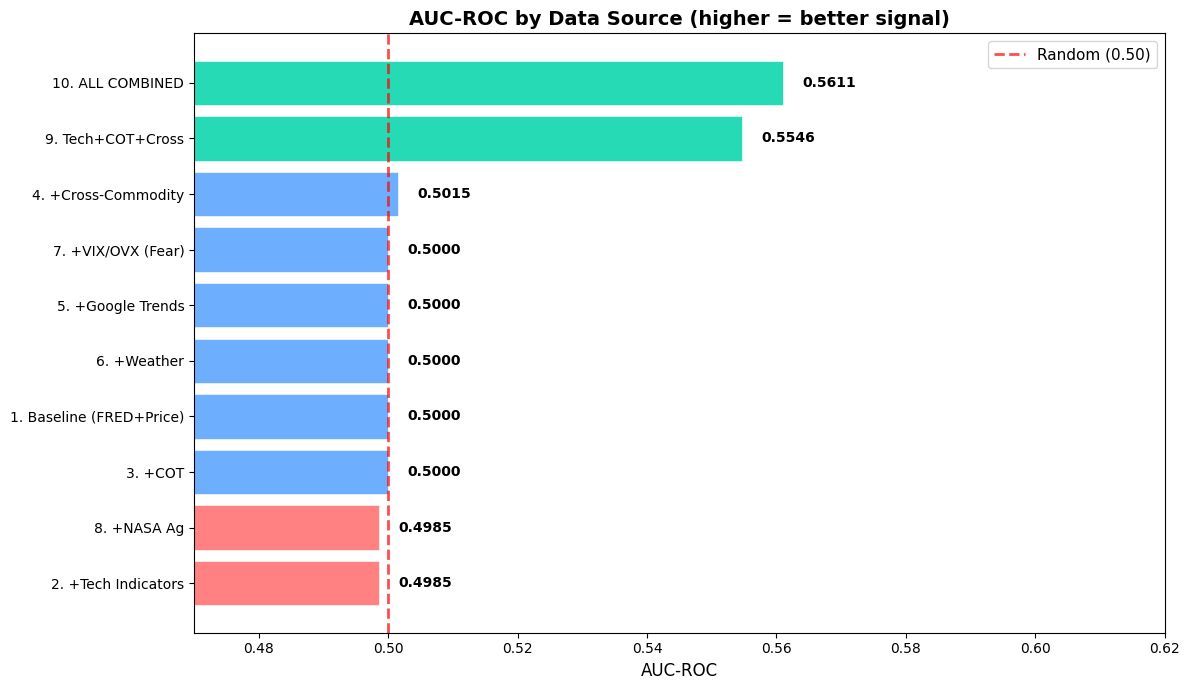

In [18]:
# AUC-ROC comparison (most reliable metric — not affected by threshold collapse)
fig, ax = plt.subplots(figsize=(12, 7))
vals = results_df['AUC-ROC'].sort_values()
colors = ['#FF6B6B' if v < 0.5 else '#54A0FF' if v < 0.55 else '#00D4AA' for v in vals.values]
bars = ax.barh(vals.index, vals.values, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Random (0.50)', linewidth=2)
for bar, val in zip(bars, vals.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('AUC-ROC', fontsize=12)
ax.set_title('AUC-ROC by Data Source (higher = better signal)', fontsize=14, fontweight='bold')
ax.set_xlim(0.47, max(0.62, vals.max() + 0.03))
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

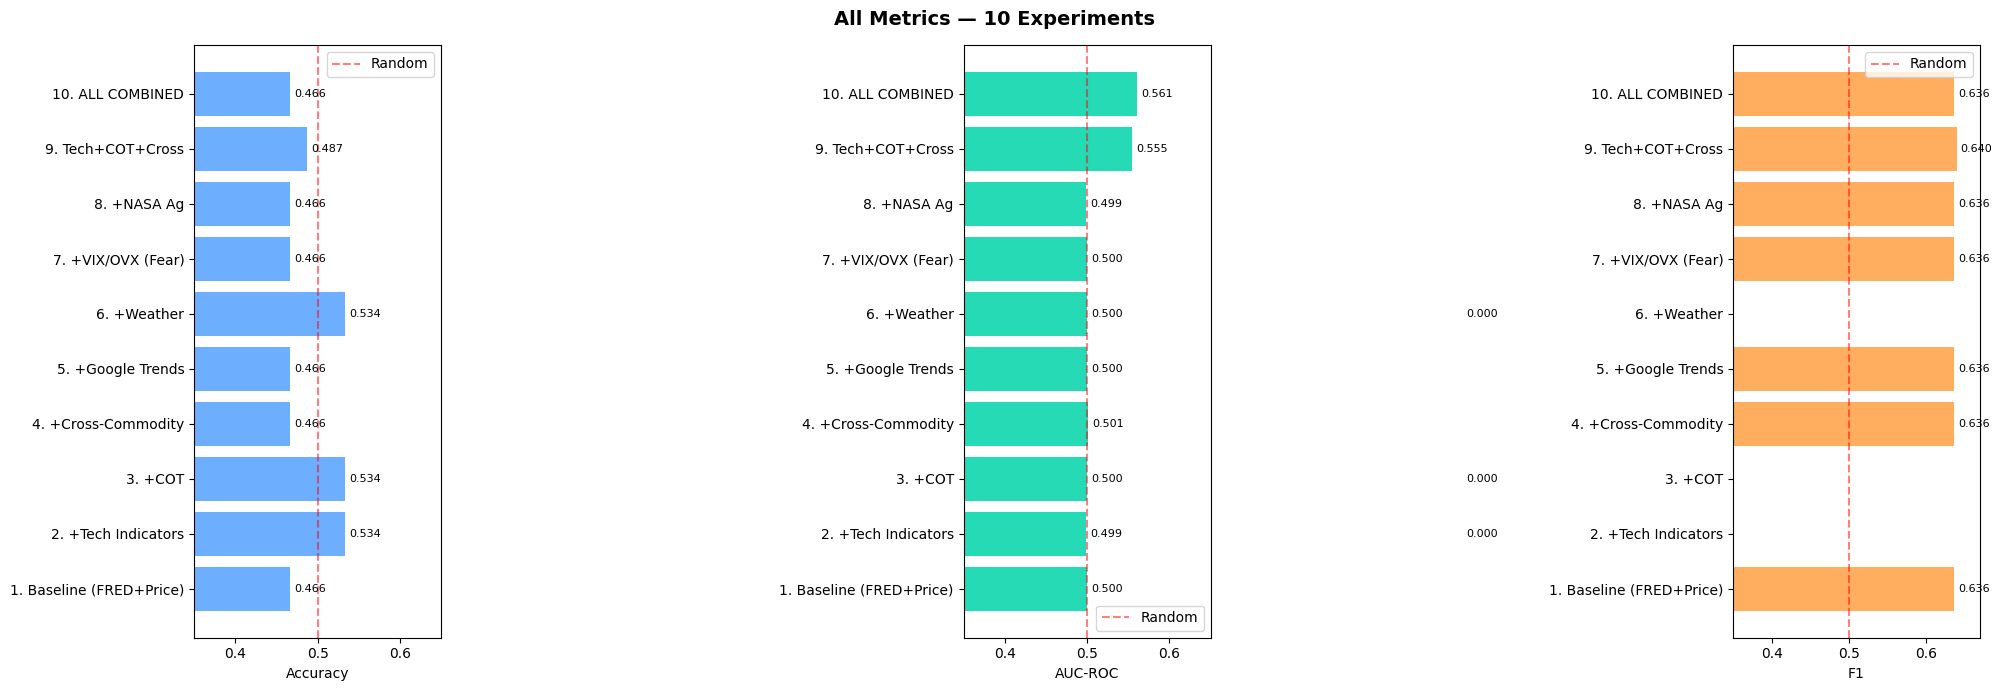

In [19]:
# All 3 metrics side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, metric, color in zip(axes, ['Accuracy','AUC-ROC','F1'], ['#54A0FF','#00D4AA','#FF9F43']):
    vals = results_df[metric]
    bars = ax.barh(vals.index, vals.values, color=color, alpha=0.85)
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
    ax.set_xlabel(metric); ax.legend()
    ax.set_xlim(0.35, max(0.65, vals.max()+0.03))
    for bar, val in zip(bars, vals.values):
        ax.text(val+0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
fig.suptitle('All Metrics — 10 Experiments', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

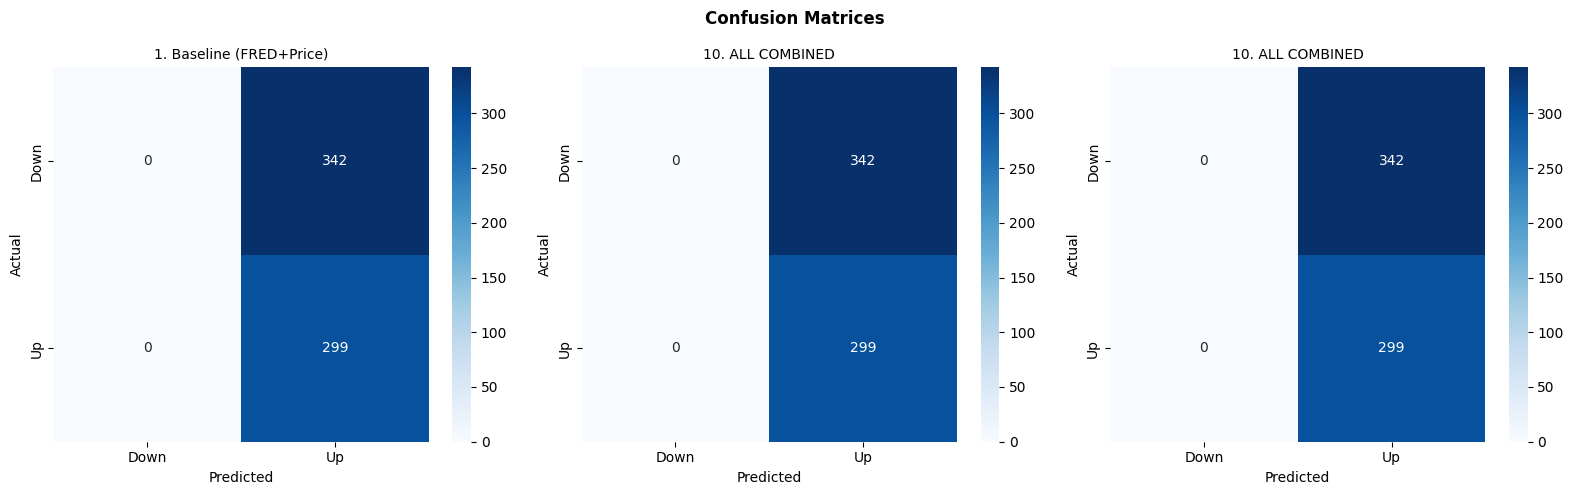

In [20]:
# Confusion matrices: Baseline vs Best individual vs ALL COMBINED
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
best_auc_name = results_df['AUC-ROC'].idxmax()
for ax, name in zip(axes, ['1. Baseline (FRED+Price)', best_auc_name, '10. ALL COMBINED']):
    p = all_preds[name]
    cm = confusion_matrix(p['y_test'], p['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Down','Up'], yticklabels=['Down','Up'])
    ax.set_title(name, fontsize=10); ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontweight='bold')
plt.tight_layout(); plt.show()

In [21]:
# Save results
out_path = os.path.join(BASE_DIR, 'alternative_data', 'processed', 'phase_test_v2_results.csv')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
results_df.to_csv(out_path)
print(f'Results saved to: {out_path}')
print()
print('KEY FINDINGS:')
print(f'  Baseline AUC:      {results_df.loc["1. Baseline (FRED+Price)","AUC-ROC"]:.4f}')
print(f'  Best single AUC:   {results_df["AUC-ROC"].max():.4f} ({results_df["AUC-ROC"].idxmax()})')
print(f'  ALL COMBINED AUC:  {results_df.loc["10. ALL COMBINED","AUC-ROC"]:.4f}')
print()
auc_improvement = results_df.loc['10. ALL COMBINED','AUC-ROC'] - results_df.loc['1. Baseline (FRED+Price)','AUC-ROC']
print(f'  AUC improvement (Baseline -> All): +{auc_improvement:.4f}')
print()
print('NEXT STEPS:')
print('  1. Try XGBoost/LightGBM (tree models dont collapse to one class)')
print('  2. Add USDA Crop Progress (needs API key registration)')
print('  3. Add real NDVI via Google Earth Engine')
print('  4. Try weekly (5-day) direction instead of daily')

Results saved to: /content/drive/MyDrive/Quants /alternative_data/processed/phase_test_v2_results.csv

KEY FINDINGS:
  Baseline AUC:      0.5000
  Best single AUC:   0.5611 (10. ALL COMBINED)
  ALL COMBINED AUC:  0.5611

  AUC improvement (Baseline -> All): +0.0611

NEXT STEPS:
  1. Try XGBoost/LightGBM (tree models dont collapse to one class)
  2. Add USDA Crop Progress (needs API key registration)
  3. Add real NDVI via Google Earth Engine
  4. Try weekly (5-day) direction instead of daily
